# Demo of Spark GraphFrames

### I. Overview

This notebook is developed to demonstrate the usage of **GraphFrames** for graph processing in Apache Spark. 

**Key Takeaways:**
* How to construct and manipulate `GraphFrame` objects (Vertices and Edges).
* Demonstrations of basic graph applications, including graph queries, motif finding, and standard graph algorithms.

### II. Construct GraphFrames

#### 2.1. Initialize Spark Sessions with GraphFrames and Hive

In [ ]:
!pip install networkx matplotlib

In [2]:
import warnings
import logging

# 1. Suppress Python warnings
warnings.filterwarnings('ignore')

# 2. Suppress PySpark logs (if using Spark)
if 'spark' in globals():
    spark.sparkContext.setLogLevel("ERROR")
logging.getLogger("py4j").setLevel(logging.ERROR)


In [3]:
import os, sys
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lit, concat

spark = SparkSession.builder \
    .appName("Credit_Card_Fraud_Graph_Processing") \
    .config("spark.jars.packages", "graphframes:graphframes:0.8.2-spark3.2-s_2.12") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("hive.metastore.uris", "thrift://hive-metastore:9083") \
    .config("spark.sql.warehouse.dir", "hdfs://namenode:9000/user/hive/warehouse") \
    .enableHiveSupport() \
    .getOrCreate()



#### 2.2. Get data from Hive (or HDFS)

In [4]:
# Read data from Hive table (assuming table name is 'credit_transaction_db.cleaned_transactions')
# Or read directly from Parquet directory on HDFS
spark.sql("USE credit_transaction_db")
df = spark.table("cleaned_transactions")

# Display Schema and record count for verification
df.printSchema()
print(f"Total transactions: {df.count():,}")

root
 |-- TRANSACTION_ID: long (nullable = true)
 |-- TX_DATETIME: timestamp (nullable = true)
 |-- CUSTOMER_ID: long (nullable = true)
 |-- TERMINAL_ID: long (nullable = true)
 |-- TX_AMOUNT: double (nullable = true)
 |-- TX_TIME_SECONDS: long (nullable = true)
 |-- TX_TIME_DAYS: integer (nullable = true)
 |-- TX_FRAUD: integer (nullable = true)
 |-- TX_FRAUD_SCENARIO: integer (nullable = true)
 |-- tx_date: date (nullable = true)
 |-- tx_hour: integer (nullable = true)
 |-- tx_day_of_week: string (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_night: integer (nullable = true)
 |-- customer_tx_count: long (nullable = true)
 |-- customer_avg_amount: double (nullable = true)
 |-- terminal_tx_count: long (nullable = true)
 |-- tx_year_month: string (nullable = true)

Total transactions: 14,158,985


#### 2.3. Define Vertices
The vertice represents customer or POS device inside the transaction.

In [5]:
from pyspark.sql.functions import concat

# Add prefix C_ for Customers
customers = df.select(concat(lit("C_"), col("CUSTOMER_ID").cast("string")).alias("id")) \
              .distinct() \
              .withColumn("type", lit("Customer"))

# Add prefix T_ for Terminals
terminals = df.select(concat(lit("T_"), col("TERMINAL_ID").cast("string")).alias("id")) \
              .distinct() \
              .withColumn("type", lit("Terminal"))

# Combine into a single Vertices table
vertices = customers.union(terminals)

print(f"Total Vertices: {vertices.count():,}")
vertices.show(5)

Total Vertices: 109,997
+------+--------+
|    id|    type|
+------+--------+
|C_4756|Customer|
|C_3628|Customer|
|C_4672|Customer|
|C_2605|Customer|
|C_5013|Customer|
+------+--------+
only showing top 5 rows



#### 2.4. Define Edges
The edge represents the transaction. According to GraphFrames conventions, the source must be the src column and the destination must be the dst column. The transaction flow will go from CUSTOMER_ID -> TERMINAL_ID.

In [6]:
# Update source and destination IDs to match the new Vertices format
edges = df.withColumn("src", concat(lit("C_"), col("CUSTOMER_ID").cast("string"))) \
          .withColumn("dst", concat(lit("T_"), col("TERMINAL_ID").cast("string")))

# Remaining columns (TX_DATETIME, TX_AMOUNT, TX_FRAUD...) automatically become Edge attributes
print(f"Total Edges: {edges.count():,}")
edges.show(5)

Total Edges: 14,158,985
+--------------+-------------------+-----------+-----------+---------+---------------+------------+--------+-----------------+----------+-------+--------------+----------+--------+-----------------+-------------------+-----------------+-------------+------+-------+
|TRANSACTION_ID|        TX_DATETIME|CUSTOMER_ID|TERMINAL_ID|TX_AMOUNT|TX_TIME_SECONDS|TX_TIME_DAYS|TX_FRAUD|TX_FRAUD_SCENARIO|   tx_date|tx_hour|tx_day_of_week|is_weekend|is_night|customer_tx_count|customer_avg_amount|terminal_tx_count|tx_year_month|   src|    dst|
+--------------+-------------------+-----------+-----------+---------+---------------+------------+--------+-----------------+----------+-------+--------------+----------+--------+-----------------+-------------------+-----------------+-------------+------+-------+
|       6724753|2019-03-13 14:49:57|       9661|      99899|     4.28|       29947797|         346|       0|                0|2019-03-13|     14|           Wed|         0|       

#### 2.5 Define Graph

In [7]:
import time
from pyspark.sql.functions import col, desc
from graphframes import GraphFrame

# Initialize Graph Network
g = GraphFrame(vertices, edges)

# Enable checkpoint directory (Required for heavy graph algorithms)
spark.sparkContext.setCheckpointDir("hdfs://namenode:9000/user/spark/checkpoints")

print(f"Number of Edges: {edges.count():,}")
print(f"Number of Vertices: {vertices.count():,}")

Number of Edges: 14,158,985
Number of Vertices: 109,997


### III. Demos

#### 3.1. Demo 1: Basic statistics - Find the POS devices with the highest transaction volume.
Scenario: Detecting a compromised POS system (Fraud Scenario 2) through the occurrence of transactions from too many different customers.
*   Requirement: Find the Top 10 Terminals with the highest number of customer payments.
*   Comparison of methods:
    *   SQL/DataFrame: Use GROUP BY + COUNT().
    *   GraphFrames: Use inDegrees.

- By Spark SQL

In [30]:
import time
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, desc

# Initialize dictionary to store execution times for all scenarios
execution_times = {}

In [31]:
print("--- DEMO 1: CALCULATING IN-DEGREE WITH SPARK SQL/DATAFRAME ---")
print(f"Number of transactions (Edges) being processed: {edges.count():,} \n")

start_sql = time.time()

# Group by destination device (dst) and count transactions
sql_indegree = edges.groupBy("dst").count().withColumnRenamed("count", "inDegree")

# Get Top 10 devices
sql_result = sql_indegree.orderBy(desc("inDegree")).limit(10)

# Action: .show() triggers processing and prints results to screen
print("Top 10 POS terminals with highest incoming transaction volume:")
sql_result.show() 

# Save execution time
time_sql = time.time() - start_sql
execution_times['Demo 1 - Spark SQL'] = time_sql

print(f"-> Processing time (Spark SQL): {time_sql:.4f} seconds\n")

--- DEMO 1: CALCULATING IN-DEGREE WITH SPARK SQL/DATAFRAME ---
Number of transactions (Edges) being processed: 14,158,985 

Top 10 POS terminals with highest incoming transaction volume:
+-------+--------+
|    dst|inDegree|
+-------+--------+
|T_11678|     254|
|T_74295|     251|
|T_55218|     249|
|T_42247|     248|
|T_43006|     246|
|T_87849|     243|
|T_90425|     243|
| T_8453|     243|
|T_67034|     242|
|T_59139|     242|
+-------+--------+

-> Processing time (Spark SQL): 1.0157 seconds



- By GraphFrames

In [32]:
print("--- DEMO 1: CALCULATING IN-DEGREE WITH GRAPHFRAMES ---")

start_gf = time.time()

# Use built-in inDegrees property of GraphFrames
gf_indegree = g.inDegrees

# Get Top 5 devices
gf_result = gf_indegree.orderBy(desc("inDegree")).limit(10)

# Action: .show() triggers processing and prints results to screen
print("Top 10 POS terminals with highest incoming transaction volume:")
gf_result.show()

# Save execution time
time_gf = time.time() - start_gf
execution_times['Demo 1 - GraphFrames'] = time_gf

print(f"-> Processing time (GraphFrames): {time_gf:.4f} seconds\n")

--- DEMO 1: CALCULATING IN-DEGREE WITH GRAPHFRAMES ---
Top 10 POS terminals with highest incoming transaction volume:
+-------+--------+
|     id|inDegree|
+-------+--------+
|T_11678|     254|
|T_74295|     251|
|T_55218|     249|
|T_42247|     248|
|T_43006|     246|
|T_87849|     243|
|T_90425|     243|
| T_8453|     243|
|T_67034|     242|
|T_59139|     242|
+-------+--------+

-> Processing time (GraphFrames): 1.0700 seconds



#### 3.2. Demo 2: Motif Finding - Detecting POS infection risks (Fraud Pattern)

Scenario: Customer A (committing fraud) transacts at POS (T1). Customer B transacts at T1 immediately afterward, risking information leakage (Phishing), and then continues to transact at POS (T2).
* Requirement: Identify POS (T2) machines at risk of chain infection: A -> T1 <- B -> T2
* Comparison of methods:
  * SQL/DataFrame (Self-Join): Uses commands to automatically join transaction tables. Complex, verbose syntax, consumes a lot of memory.
  * GraphFrames: Intuitive syntax, easy to read, optimized performance, and a significantly better programming experience when querying complex linked strings.


In [14]:
print("--- INITIALIZING SAMPLE DATA (1 MONTH) FOR ADVANCED DEMOS ---")

# Sample data for April 2018
edges_sample = edges.filter(col("tx_year_month") == "2018-04")

# Filter Vertices corresponding to the sample Edges
sample_customers = edges_sample.select(col("src").alias("id")).distinct().withColumn("type", lit("Customer"))
sample_terminals = edges_sample.select(col("dst").alias("id")).distinct().withColumn("type", lit("Terminal"))
vertices_sample = sample_customers.union(sample_terminals)

# Initialize sample GraphFrame
g_sample = GraphFrame(vertices_sample, edges_sample)

print(f"Number of Edges (Sample): {edges_sample.count():,}")
print(f"Number of Vertices (Sample): {vertices_sample.count():,}")

--- INITIALIZING SAMPLE DATA (1 MONTH) FOR ADVANCED DEMOS ---
Number of Edges (Sample): 582,506
Number of Vertices (Sample): 109,501


- By Spark SQL

In [33]:
print("--- DEMO 2: CROSS-INFECTION MOTIF SEARCH WITH SPARK SQL (COMPLEX SELF-JOIN) ---")

start_sql2 = time.time()

# SQL requires 3 Self-Joins on edges_sample with complex filtering logic
sql_pattern = edges_sample.alias("e1") \
    .join(edges_sample.alias("e2"), col("e1.dst") == col("e2.dst")) \
    .join(edges_sample.alias("e3"), col("e2.src") == col("e3.src")) \
    .filter(
        (col("e1.src") != col("e2.src")) &                      # A is different from B
        (col("e1.dst") != col("e3.dst")) &                      # T1 is different from T2
        (col("e1.TX_FRAUD") == 1) &                             # Transaction 1 is fraudulent
        (col("e2.TX_FRAUD") == 0) & (col("e3.TX_FRAUD") == 0) & # Transactions 2 and 3 are normal
        (col("e2.TX_TIME_SECONDS") > col("e1.TX_TIME_SECONDS")) & # B swipes after A at T1
        (col("e3.TX_TIME_SECONDS") > col("e2.TX_TIME_SECONDS"))   # B swipes at T2 after swiping at T1
    )

# Normalize display columns
sql_result2 = sql_pattern.select(
    col("e1.src").alias("Fraud_Customer_A"), 
    col("e1.dst").alias("Infected_POS_T1"), 
    col("e2.src").alias("Victim_Customer_B"),
    col("e3.dst").alias("At_Risk_POS_T2")
).dropDuplicates()

print(f"Total infection chains found by SQL: {sql_result2.count()}")
print("Top 10 infection chains found:")
# sql_result2.show()
sql_result2.orderBy("Fraud_Customer_A", "Infected_POS_T1", "Victim_Customer_B","At_Risk_POS_T2").show(10, truncate=False)

# Save execution time
time_sql2 = time.time() - start_sql2
execution_times['Demo 2 - Spark SQL'] = time_sql2

print(f"-> Processing time (Spark DataFrame): {time_sql2:.4f} seconds\n")

--- DEMO 2: CROSS-INFECTION MOTIF SEARCH WITH SPARK SQL (COMPLEX SELF-JOIN) ---
Total infection chains found by SQL: 52044
Top 10 infection chains found:
+----------------+---------------+-----------------+--------------+
|Fraud_Customer_A|Infected_POS_T1|Victim_Customer_B|At_Risk_POS_T2|
+----------------+---------------+-----------------+--------------+
|C_1051          |T_28176        |C_7254           |T_12431       |
|C_1051          |T_28176        |C_7254           |T_1438        |
|C_1051          |T_28176        |C_7254           |T_16339       |
|C_1051          |T_28176        |C_7254           |T_22967       |
|C_1051          |T_28176        |C_7254           |T_32199       |
|C_1051          |T_28176        |C_7254           |T_33403       |
|C_1051          |T_28176        |C_7254           |T_36640       |
|C_1051          |T_28176        |C_7254           |T_40890       |
|C_1051          |T_28176        |C_7254           |T_44915       |
|C_1051          |T_28176     

- By GraphFrames

In [34]:
print("--- DEMO 2: CROSS-INFECTION MOTIF SEARCH WITH GRAPHFRAMES (MOTIF FINDING) ---")

start_gf2 = time.time()

# Intuitive Motif syntax simulating sequence: A to T1, B to T1, B to T2
motifs = g_sample.find("(a)-[e1]->(t1); (b)-[e2]->(t1); (b)-[e3]->(t2)")

# Filter conditions cleanly on Motif
gf_pattern = motifs.filter("""
    a.id != b.id AND t1.id != t2.id AND 
    e1.TX_FRAUD = 1 AND e2.TX_FRAUD = 0 AND e3.TX_FRAUD = 0 AND 
    e2.TX_TIME_SECONDS > e1.TX_TIME_SECONDS AND 
    e3.TX_TIME_SECONDS > e2.TX_TIME_SECONDS
""")

# Normalize display columns identically to SQL
gf_result2 = gf_pattern.select(
    col("a.id").alias("Fraud_Customer_A"), 
    col("t1.id").alias("Infected_POS_T1"), 
    col("b.id").alias("Victim_Customer_B"),
    col("t2.id").alias("At_Risk_POS_T2")
).dropDuplicates()

print(f"Total infection chains found by GraphFrames: {gf_result2.count()}")
print("Top 10 infection chains found:")
# gf_result2.show()
gf_result2.orderBy("Fraud_Customer_A", "Infected_POS_T1", "Victim_Customer_B","At_Risk_POS_T2").show(10, truncate=False)

# Save execution time
time_gf2 = time.time() - start_gf2
execution_times['Demo 2 - GraphFrames'] = time_gf2

print(f"-> Processing time (GraphFrames Motif Finding): {time_gf2:.4f} seconds\n")

--- DEMO 2: CROSS-INFECTION MOTIF SEARCH WITH GRAPHFRAMES (MOTIF FINDING) ---
Total infection chains found by GraphFrames: 52044
Top 10 infection chains found:
+----------------+---------------+-----------------+--------------+
|Fraud_Customer_A|Infected_POS_T1|Victim_Customer_B|At_Risk_POS_T2|
+----------------+---------------+-----------------+--------------+
|C_1051          |T_28176        |C_7254           |T_12431       |
|C_1051          |T_28176        |C_7254           |T_1438        |
|C_1051          |T_28176        |C_7254           |T_16339       |
|C_1051          |T_28176        |C_7254           |T_22967       |
|C_1051          |T_28176        |C_7254           |T_32199       |
|C_1051          |T_28176        |C_7254           |T_33403       |
|C_1051          |T_28176        |C_7254           |T_36640       |
|C_1051          |T_28176        |C_7254           |T_40890       |
|C_1051          |T_28176        |C_7254           |T_44915       |
|C_1051          |T_2817

#### 3.3. Demo 3: Shortest Path (Breadth-First Search - BFS) - Risk Line Tracing

Scenario: Suppose a fraudulent customer (Risk Customer) is identified, and you want to trace how many hops away this customer is from other customers (via shared POS terminals).
*   Requirement: Find the shortest path (within 4 hops) from the fraudulent Customer to normal Customers to issue card freeze alerts.
*   Comparison of methods:
    *   SQL/DataFrame: Skipped because pure Spark SQL is nearly impossible or extremely difficult for variable-depth path queries without Recursive CTEs or iterative Python loops with continuous Joins.
    *   GraphFrames: Use `g.bfs()`.

- GraphFrames

In [35]:
print("--- DEMO 3: INFECTION TRACING WITH GRAPHFRAMES (Breadth-First Search) ---")
start_gf3 = time.time()

# 1. Create reverse edges to handle directed graph traversal (Bidirectional Graph)
reverse_edges = edges_sample.select(
    col("dst").alias("src"), 
    col("src").alias("dst"),
    "TX_AMOUNT", "TX_DATETIME", "TX_TIME_SECONDS", "TX_FRAUD"
)

# 2. Combine original and reversed edges
bidirectional_edges = edges_sample.select("src", "dst", "TX_AMOUNT", "TX_DATETIME", "TX_TIME_SECONDS", "TX_FRAUD") \
    .unionByName(reverse_edges)

# 3. Re-initialize Graph with bidirectional edges
g_bidirectional = GraphFrame(vertices_sample, bidirectional_edges)

# 4. Run BFS (Find cross-infection paths up to 4 hops)
paths = g_bidirectional.bfs(
    fromExpr="id = 'C_1051'",               
    toExpr="type = 'Customer' AND id != 'C_1051'", 
    maxPathLength=4                         
)

# 5. NORMALIZE DISPLAY COLUMNS TO MATCH SPARK SQL
available_cols = paths.columns

select_exprs = [col("from.id").alias("Source_Customer")]
if "v1" in available_cols:
    select_exprs.append(col("v1.id").alias("POS_Hop_1"))
if "v2" in available_cols:
    select_exprs.append(col("v2.id").alias("Customer_Hop_2"))
if "v3" in available_cols:
    select_exprs.append(col("v3.id").alias("POS_Hop_3"))
if "to" in available_cols:
    select_exprs.append(col("to.id").alias("Customer_Hop_4"))

gf_result3_formatted = paths.select(*select_exprs).dropDuplicates()

# Action
count_paths = gf_result3_formatted.count()
time_gf3 = time.time() - start_gf3

print(f"Found {count_paths} cross-infection paths (4 hops).")
if count_paths > 0:
    print("Shortest infection paths list:")
    gf_result3_formatted.show(5, truncate=False)
else:
    print("No shared POS path found for this customer in sample set with maxPathLength=4.")

# Save execution time
execution_times['Demo 3 - GraphFrames (BFS)'] = time_gf3

print(f"-> Processing time (GraphFrames BFS): {time_gf3:.4f} seconds\n")

--- DEMO 3: INFECTION TRACING WITH GRAPHFRAMES (Breadth-First Search) ---
Found 289 cross-infection paths (4 hops).
Shortest infection paths list:
+---------------+---------+--------------+
|Source_Customer|POS_Hop_1|Customer_Hop_4|
+---------------+---------+--------------+
|C_1051         |T_53436  |C_5774        |
|C_1051         |T_53436  |C_8924        |
|C_1051         |T_53436  |C_7548        |
|C_1051         |T_53436  |C_2462        |
|C_1051         |T_53436  |C_2153        |
+---------------+---------+--------------+
only showing top 5 rows

-> Processing time (GraphFrames BFS): 4.5999 seconds



#### 3.4. Demo 4: Community Detection (Label Propagation Algorithm - LPA)

*   Background: Organized credit card fraud (Fraud Scenario 3) typically involves groups/clusters of transactions conducted together.
*   Scenario: Using the Label Propagation Algorithm (LPA), we can automatically detect groups/communities of credit cards and POS devices that frequently interact with each other.
*   Comparison of methods:
    *   SQL/DataFrame: Skipped, as pure SQL does not support network Machine Learning/Graph Analytics algorithms.
    *   GraphFrames: Execute `g.labelPropagation(maxIter=3)`.

In [38]:
print("--- DEMO 4: GRAPH ANALYTICS - LABEL PROPAGATION ALGORITHM (LPA) ---")

print("Starting LPA execution (May take seconds to minutes depending on cluster config)...")
start_gf4 = time.time()

# maxIter=3 for fast demo execution. In practice use 5-10
result_lpa = g_sample.labelPropagation(maxIter=3)

# Count number of communities (Each community is assigned a unique label)
num_communities = result_lpa.select("label").distinct().count()

print(f"Graph partitioned into {num_communities} independent communities.")

# Display 5 nodes belonging to a random community cluster
sample_label = result_lpa.select("label").first()[0]
result_lpa.filter(col("label") == sample_label).show(5)

# Save execution time
time_gf4 = time.time() - start_gf4
execution_times['Demo 4 - GraphFrames (LPA)'] = time_gf4

print(f"-> Processing time (GraphFrames BFS): {time_gf4:.4f} seconds\n")

--- DEMO 4: GRAPH ANALYTICS - LABEL PROPAGATION ALGORITHM (LPA) ---
Starting LPA execution (May take seconds to minutes depending on cluster config)...
Graph partitioned into 12683 independent communities.
+------+--------+-----+
|    id|    type|label|
+------+--------+-----+
|C_3465|Customer|46369|
|C_4299|Customer|46369|
|C_6099|Customer|46369|
|C_8417|Customer|46369|
|C_7714|Customer|46369|
+------+--------+-----+
only showing top 5 rows

-> Processing time (GraphFrames BFS): 34.3789 seconds



#### 3.5. Visualize Demo Results

- Performance Comparison (Spark SQL vs GraphFrames)

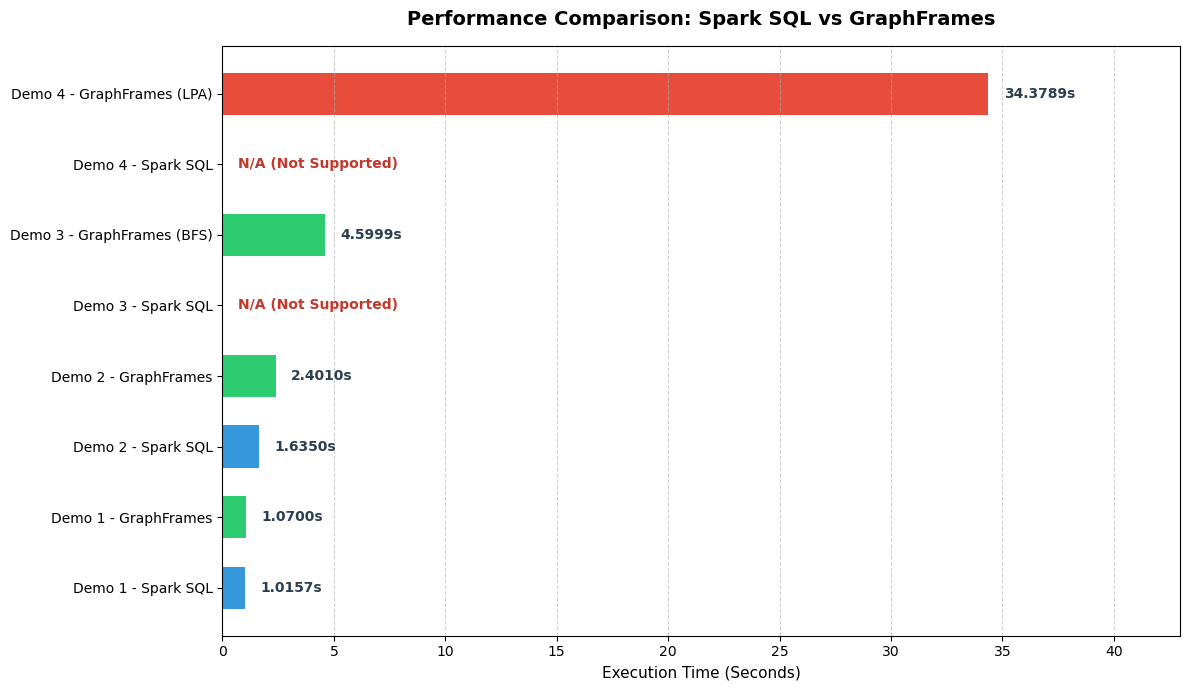

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Cấu hình dictionary thời gian xử lý với giá trị NaN cho Spark SQL ở Demo 3 & Demo 4
execution_times_custom = {
    'Demo 1 - Spark SQL': execution_times.get('Demo 1 - Spark SQL', ),
    'Demo 1 - GraphFrames': execution_times.get('Demo 1 - GraphFrames'),
    'Demo 2 - Spark SQL': execution_times.get('Demo 2 - Spark SQL'),
    'Demo 2 - GraphFrames': execution_times.get('Demo 2 - GraphFrames'),
    'Demo 3 - Spark SQL': np.nan,  # Spark SQL does not support Native BFS
    'Demo 3 - GraphFrames (BFS)': execution_times.get('Demo 3 - GraphFrames (BFS)'),
    'Demo 4 - Spark SQL': np.nan,  # Spark SQL does not support LPA
    'Demo 4 - GraphFrames (LPA)': execution_times.get('Demo 4 - GraphFrames (LPA)')
}

df_perf = pd.DataFrame(list(execution_times_custom.items()), columns=['Scenario', 'Time_Seconds'])

plt.figure(figsize=(12, 7))

# Thay giá trị NaN bằng 0 khi truyền vào barh để matplotlib vẽ trục chuẩn xác
plot_values = df_perf['Time_Seconds'].fillna(0)

# Đặt màu sắc (màu xám nhạt cho các kịch bản N/A)
colors = ['#3498db', '#2ecc71', '#3498db', '#2ecc71', '#bdc3c7', '#2ecc71', '#bdc3c7', '#e74c3c']

bars = plt.barh(df_perf['Scenario'], plot_values, color=colors, height=0.6)

max_time = df_perf['Time_Seconds'].dropna().max()
plt.xlim(0, max_time * 1.25)

# Đánh nhãn kết quả cho từng thanh
for bar, val in zip(bars, df_perf['Time_Seconds']):
    y_pos = bar.get_y() + bar.get_height() / 2
    if pd.isna(val):
        # Hiển thị chữ N/A (Not Supported) màu đỏ cho kịch bản NaN
        plt.text(max_time * 0.02, y_pos, 'N/A (Not Supported)', 
                 va='center', ha='left', fontsize=10, fontweight='bold', color='#c0392b')
    else:
        plt.text(val + (max_time * 0.02), y_pos, f'{val:.4f}s', 
                 va='center', ha='left', fontsize=10, fontweight='bold', color='#2c3e50')

plt.title('Performance Comparison: Spark SQL vs GraphFrames', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Execution Time (Seconds)', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


- Demo 1: Transaction Network of Top 10 Highest Volume POS Terminals

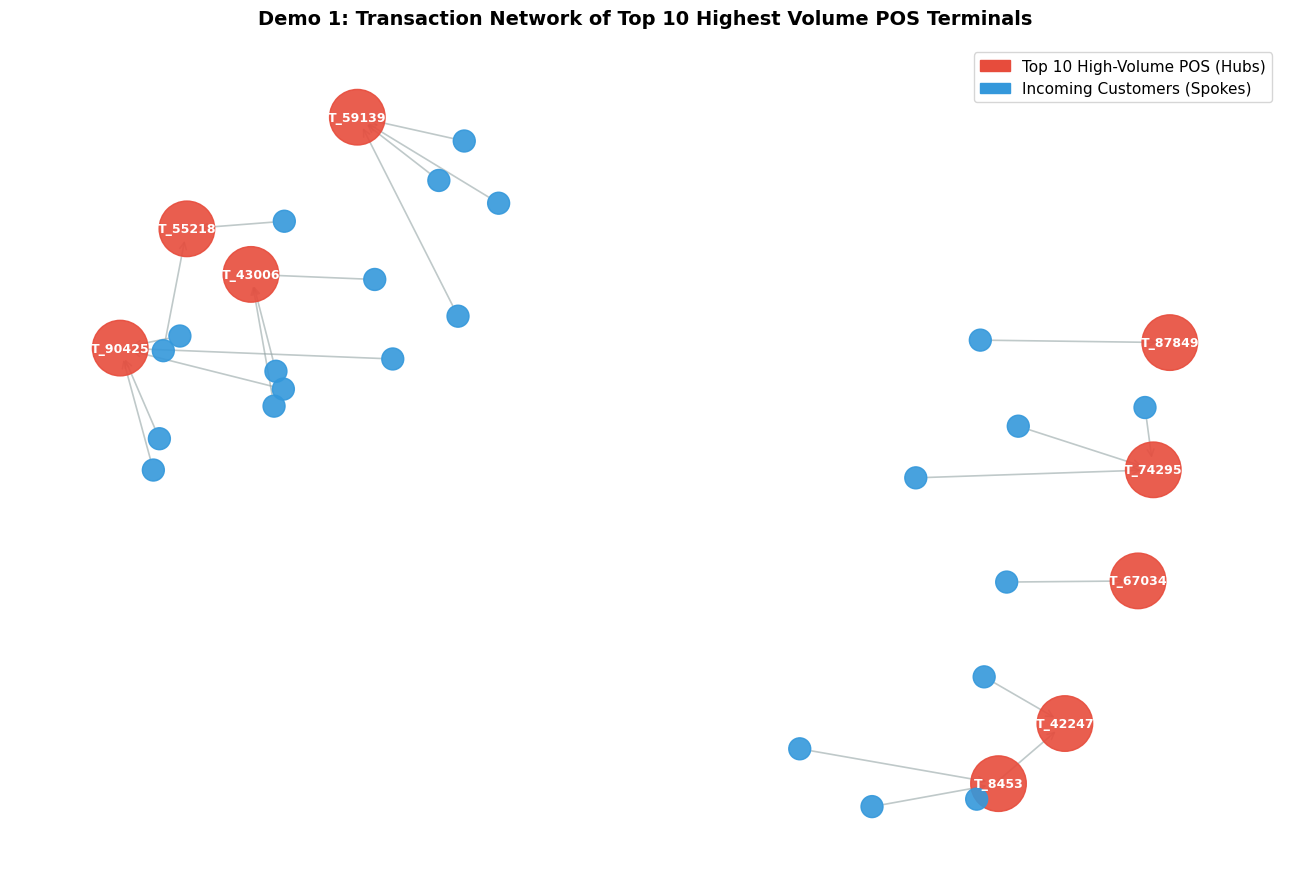

In [44]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pyspark.sql.functions import col, desc

# 1. Lấy danh sách ID của Top 10 POS terminals có inDegree cao nhất từ Demo 1
top_10_pos_df = gf_indegree.orderBy(desc("inDegree")).limit(10)
top_10_pos_ids = [row['id'] for row in top_10_pos_df.collect()]

# 2. Lọc các giao dịch hướng tới Top 10 máy POS này
# (Lấy mẫu ngẫu nhiên khoảng 80-100 giao dịch để sơ đồ không bị rối mắt)
top_edges = edges.filter(col("dst").isin(top_10_pos_ids)) \
                 .select("src", "dst") \
                 .sample(withReplacement=False, fraction=0.01, seed=42) \
                 .limit(100) \
                 .collect()

# 3. Tạo đồ thị có hướng (DiGraph) với NetworkX
G_top10 = nx.DiGraph()

for row in top_edges:
    customer = row['src']
    pos_terminal = row['dst']
    G_top10.add_edge(customer, pos_terminal)

# 4. Phân loại màu sắc và kích thước nút
node_colors = []
node_sizes = []

for node in G_top10.nodes():
    if node in top_10_pos_ids:
        node_colors.append('#e74c3c') # Đỏ nổi bật cho Top 10 POS Hubs
        node_sizes.append(1600)
    else:
        node_colors.append('#3498db') # Xanh dương cho Customers
        node_sizes.append(250)

# 5. Tiến hành hiển thị mạng lưới
plt.figure(figsize=(13, 9))
pos = nx.spring_layout(G_top10, seed=42, k=0.35)

# Vẽ nút và cạnh
nx.draw_networkx_nodes(G_top10, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_edges(G_top10, pos, arrowstyle='->', arrowsize=12, edge_color='#95a5a6', alpha=0.6, width=1.2)

# Chỉ hiển thị tên cho Top 10 máy POS để màn hình gọn gàng
pos_labels = {n: n for n in G_top10.nodes() if n in top_10_pos_ids}
nx.draw_networkx_labels(G_top10, pos, labels=pos_labels, font_size=9, font_weight='bold', font_color='white')

# Bảng chú thích (Legend)
pos_patch = mpatches.Patch(color='#e74c3c', label='Top 10 High-Volume POS (Hubs)')
cust_patch = mpatches.Patch(color='#3498db', label='Incoming Customers (Spokes)')
plt.legend(handles=[pos_patch, cust_patch], loc='upper right', fontsize=11)

plt.title('Demo 1: Transaction Network of Top 10 Highest Volume POS Terminals', fontsize=14, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()


- Demo 2: Cross-Infection Motif Graph Visualization

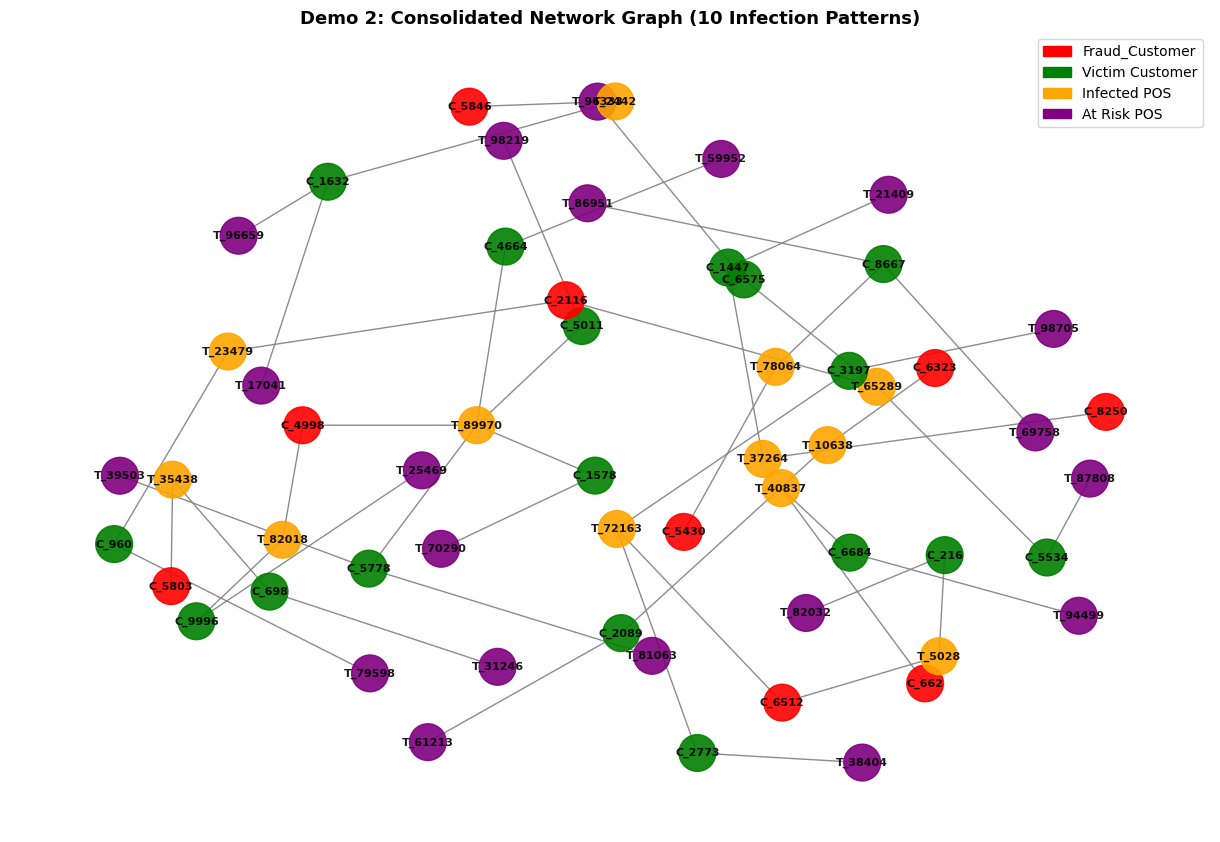

In [63]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Chuyển đổi khoảng 20 chuỗi từ kết quả GraphFrames sang Pandas DataFrame
sample_patterns_pd = gf_result2.limit(20).toPandas()

# Khởi tạo đồ thị NetworkX
G = nx.Graph()

# Duyệt qua các dòng và thêm Node/Edge
for _, row in sample_patterns_pd.iterrows():
    fraud_node = row['Fraud_Customer_A']
    terminal_1 = row['Infected_POS_T1']
    victim_node = row['Victim_Customer_B']
    terminal_2 = row['At_Risk_POS_T2']
    
    # Thêm Node với thuộc tính màu sắc để phân biệt
    G.add_node(fraud_node, color='red')          # Kẻ gian lận
    G.add_node(terminal_1, color='orange')       # POS bị nhiễm
    G.add_node(victim_node, color='green')       # Nạn nhân
    G.add_node(terminal_2, color='purple')       # POS rủi ro
    
    # Thêm các cạnh nối (Giao dịch)
    G.add_edge(fraud_node, terminal_1)
    G.add_edge(victim_node, terminal_1)
    G.add_edge(victim_node, terminal_2)

# Lấy mảng màu sắc cho các node đã add
color_map = [nx.get_node_attributes(G, 'color').get(node, 'gray') for node in G.nodes()]

# Thiết lập và vẽ đồ thị
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.6) # Thuật toán dàn trang Spring Layout
nx.draw(G, pos, with_labels=True, node_color=color_map, node_size=700, font_size=8, font_weight="bold", edge_color="gray", alpha=0.9)

# Tạo chú thích (Legend)
red_patch = mpatches.Patch(color='red', label='Fraud_Customer')
green_patch = mpatches.Patch(color='green', label='Victim Customer')
orange_patch = mpatches.Patch(color='orange', label='Infected POS')
purple_patch = mpatches.Patch(color='purple', label='At Risk POS')
plt.legend(handles=[red_patch, green_patch, orange_patch, purple_patch], loc='upper right')

plt.title(f'Demo 2: Consolidated Network Graph ({num_patterns} Infection Patterns)', fontsize=13, fontweight='bold')
plt.show()

- Demo 3:

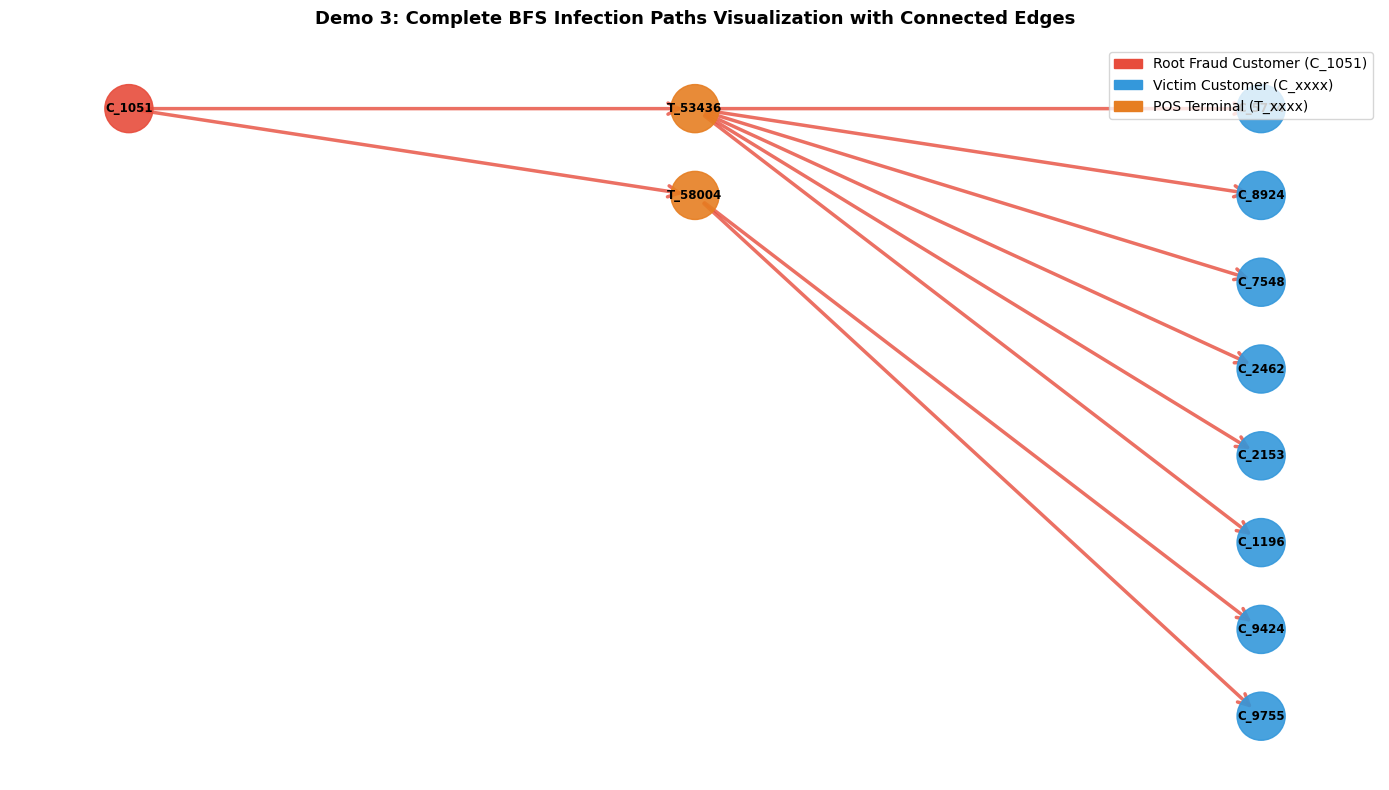

In [50]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Lấy 8 đường đi BFS mẫu
bfs_sample = gf_result3_formatted.limit(8).collect()

G_bfs = nx.DiGraph()
pos = {}

level_counts = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0}

for row_idx, row in enumerate(bfs_sample):
    r = row.asDict()
    
    # Lấy danh sách tất cả các đỉnh hợp lệ (không phải None) trong chuỗi đường đi này
    path_nodes = [str(val) for val in r.values() if val is not None]
    
    # Thêm nút & xác định tọa độ phân tầng
    for level, node in enumerate(path_nodes):
        if node not in G_bfs:
            # Gán màu dựa vào loại đỉnh (Khách hàng vs POS)
            color = '#e74c3c' if level == 0 else ('#3498db' if node.startswith('C_') else '#e67e22')
            G_bfs.add_node(node, level=level, color=color)
            
            level_counts[level] = level_counts.get(level, 0) + 1
            pos[node] = (level * 2.5, -level_counts[level] * 1.3)

    # NỐI TẤT CẢ CÁC CẶP ĐỈNH LIÊN TIẾP TRONG CHUỖI ĐƯỜNG ĐỊ (Node_i -> Node_i+1)
    for i in range(len(path_nodes) - 1):
        src_node = path_nodes[i]
        dst_node = path_nodes[i+1]
        G_bfs.add_edge(src_node, dst_node)

plt.figure(figsize=(14, 8))

node_colors = [G_bfs.nodes[n]['color'] for n in G_bfs.nodes()]

# 2. Vẽ nút
nx.draw_networkx_nodes(G_bfs, pos, node_color=node_colors, node_size=1200, alpha=0.9)

# 3. Vẽ CẠNH VỚI MŨI TÊN NỐI RÕ RÀNG GIỮA CÁC ĐỈNH
nx.draw_networkx_edges(
    G_bfs, pos, 
    arrowstyle='->', 
    arrowsize=20, 
    edge_color='#e74c3c', # Màu đỏ cam đậm cho đường nối dễ quan sát
    width=2.5, 
    alpha=0.8
)

# 4. Hiển thị nhãn tên đỉnh
nx.draw_networkx_labels(G_bfs, pos, font_size=8.5, font_weight='bold', font_color='black')

# Bảng chú thích
p_root = mpatches.Patch(color='#e74c3c', label='Root Fraud Customer (C_1051)')
p_cust = mpatches.Patch(color='#3498db', label='Victim Customer (C_xxxx)')
p_pos  = mpatches.Patch(color='#e67e22', label='POS Terminal (T_xxxx)')
plt.legend(handles=[p_root, p_cust, p_pos], loc='upper right', fontsize=10)

plt.title('Demo 3: Complete BFS Infection Paths Visualization with Connected Edges', fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()


- Demo 4: LPA Community Subgraph Visualization

📌 Community [5242]: 32 Customers, 20 POS terminals | ⚠️ There are 3 fraud customers


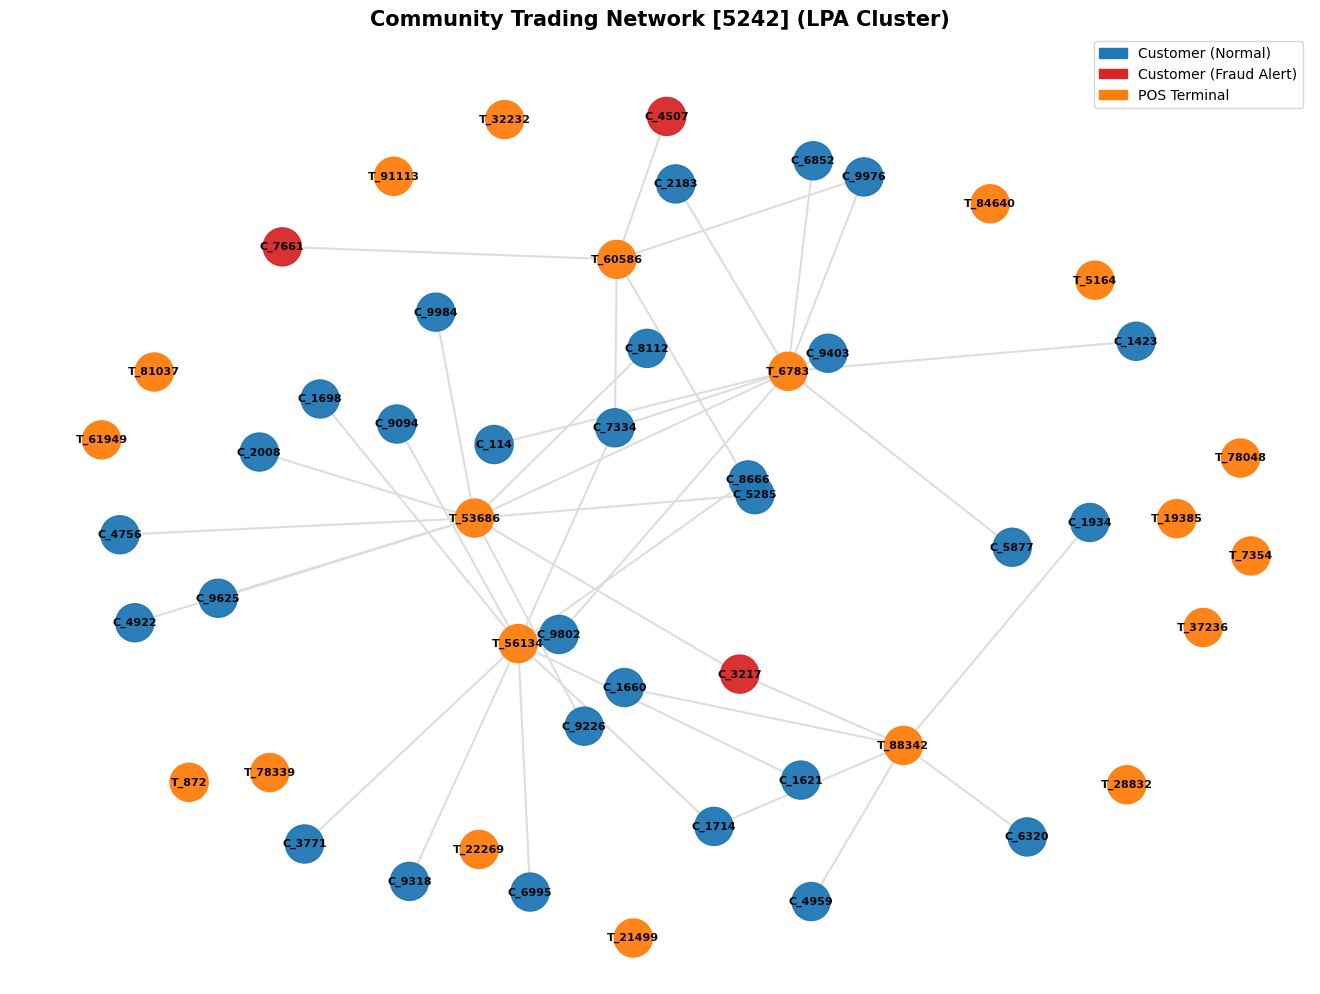

In [68]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from pyspark.sql.functions import col, desc, max as spark_max

if 'result_lpa' in globals():
    # 1. Tìm nhãn cộng đồng có nhiều thành viên nhất
    top_community_row = result_lpa.groupBy("label").count().orderBy(desc("count")).limit(1).collect()
    
    if top_community_row:
        top_label = top_community_row[0]["label"]
        
        # 2. Trích xuất nút Customer & Terminal thuộc cụm
        nodes_in_community = result_lpa.filter(col("label") == top_label)
        cust_nodes = nodes_in_community.filter(col("type") == "Customer").limit(20)
        term_nodes = nodes_in_community.filter(col("type") == "Terminal").limit(20)
        
        community_nodes_pd = cust_nodes.union(term_nodes).toPandas()
        node_ids = community_nodes_pd['id'].tolist()

        # 3. Lọc cạnh giao dịch nội bộ
        community_edges_pd = edges_sample.filter(
            col("src").isin(node_ids) & col("dst").isin(node_ids)
        ).toPandas()
        
        if community_edges_pd.empty:
            community_edges_pd = edges_sample.filter(
                col("src").isin(node_ids) | col("dst").isin(node_ids)
            ).limit(40).toPandas()
            
            extra_src = community_edges_pd['src'].tolist()
            extra_dst = community_edges_pd['dst'].tolist()
            all_node_ids = list(set(node_ids + extra_src + extra_dst))
            community_nodes_pd = result_lpa.filter(col("id").isin(all_node_ids)).toPandas()

        # 4. Kiểm tra thông tin Gian lận từ edges_sample
        fraud_customers = edges_sample.filter(col("TX_FRAUD") == 1).select("src").distinct().toPandas()['src'].tolist()

        # In thống kê nhanh về cụm
        num_cust = len(community_nodes_pd[community_nodes_pd['type'] == 'Customer'])
        num_term = len(community_nodes_pd[community_nodes_pd['type'] == 'Terminal'])
        num_fraud_cust = len([cid for cid in community_nodes_pd['id'] if cid in fraud_customers])

        print(f"📌 Community [{top_label}]: {num_cust} Customers, {num_term} POS terminals | ⚠️ There are {num_fraud_cust} fraud customers")

        # 5. Xây dựng đồ thị NetworkX
        G_comm = nx.Graph()
        color_map_comm = []
        
        for _, row in community_nodes_pd.iterrows():
            nid = row['id']
            if row['type'] == 'Customer':
                if nid in fraud_customers:
                    color = '#d62728' # Màu đỏ: Khách hàng Gian lận
                else:
                    color = '#1f77b4' # Màu xanh: Khách hàng Bình thường
            else:
                color = '#ff7f0e'     # Màu cam: POS Terminal
                
            G_comm.add_node(nid, color=color)

        for _, row in community_edges_pd.iterrows():
            G_comm.add_edge(row['src'], row['dst'])

        color_map_comm = [nx.get_node_attributes(G_comm, 'color').get(node, 'gray') for node in G_comm.nodes()]

        # 6. Vẽ biểu đồ đồ thị
        plt.figure(figsize=(13, 9.5))
        pos_comm = nx.spring_layout(G_comm, k=0.65, seed=42)
        
        nx.draw(
            G_comm, 
            pos_comm, 
            with_labels=True, 
            node_color=color_map_comm, 
            node_size=750, 
            font_size=8, 
            font_weight='bold',
            edge_color="gainsboro",
            width=1.5,
            alpha=0.95
        )
        
        # Legend chú thích 3 nhóm rõ ràng
        blue_patch = mpatches.Patch(color='#1f77b4', label='Customer (Normal)')
        red_patch = mpatches.Patch(color='#d62728', label='Customer (Fraud Alert)')
        orange_patch = mpatches.Patch(color='#ff7f0e', label='POS Terminal')
        
        plt.legend(handles=[blue_patch, red_patch, orange_patch], loc='upper right', fontsize=10, frameon=True)
        plt.title(f"Community Trading Network [{top_label}] (LPA Cluster)", fontsize=15, fontweight='bold')
        plt.show()
    else:
        print("There is no community label")

### IV. Conclusions

* **Basic Analytics**: Both Spark SQL and GraphFrames deliver high and comparable performance for standard aggregations (e.g., In-Degree transaction counts).
* **GraphFrames Core Strengths**:
  * **Motif Finding**: Provides intuitive, readable, and clean syntax for complex fraud pattern matching compared to verbose SQL self-joins.
  * **Graph Algorithms**: Native support for Breadth-First Search (BFS) risk tracing and Label Propagation (LPA) community detection, which are not supported in native Spark SQL.
* **Business Impact**: Graph features engineered from GraphFrames serve as high-value inputs for PySpark MLlib models to boost credit card fraud prediction accuracy.